In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [ ]:
X,y = load_iris(return_X_y=True)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

In [ ]:
gnb.fit(x_train, y_train)

In [ ]:
y_pred = gnb.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))
print(accuracy_score(y_pred, y_test))

In [47]:
import seaborn as sns


In [48]:
df = sns.load_dataset('tips')

In [49]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [50]:
### Independent and dependent variable

x = df[['total_bill', 'tip', 'sex', 'smoker', 'day']]
y = df['time']

In [51]:
### Train test split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state = 42)

In [52]:
x_train

,total_bill,tip,sex,smoker,day
115,17.31,3.50,Female,No,Sun
181,23.33,5.65,Male,Yes,Sun
225,16.27,2.50,Female,Yes,Fri
68,20.23,2.01,Male,No,Sat
104,20.92,4.08,Female,No,Sat
...,...,...,...,...,...
106,20.49,4.06,Male,Yes,Sat
14,14.83,3.02,Female,No,Sun
92,5.75,1.00,Female,Yes,Fri
179,34.63,3.55,Male,Yes,Sun


In [53]:
y_train

115    Dinner
181    Dinner
225     Lunch
68     Dinner
104    Dinner
        ...  
106    Dinner
14     Dinner
92     Dinner
179    Dinner
102    Dinner
Name: time, Length: 183, dtype: category
Categories (2, str): ['Lunch', 'Dinner']

In [54]:
df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [55]:
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
le_smoker = LabelEncoder()

x_train['sex'] = le_sex.fit_transform(x_train['sex'])
x_test['sex'] = le_sex.transform(x_test['sex'])

x_train['smoker'] = le_smoker.fit_transform(x_train['smoker'])
x_test['smoker'] = le_smoker.transform(x_test['smoker'])

In [56]:
x_train

,total_bill,tip,sex,smoker,day
115,17.31,3.50,0,0,Sun
181,23.33,5.65,1,1,Sun
225,16.27,2.50,0,1,Fri
68,20.23,2.01,1,0,Sat
104,20.92,4.08,0,0,Sat
...,...,...,...,...,...
106,20.49,4.06,1,1,Sat
14,14.83,3.02,0,0,Sun
92,5.75,1.00,0,1,Fri
179,34.63,3.55,1,1,Sun


In [57]:
### using one hot encode for day : cause it contains 4 values


## Onehot encoding--- ColumnTrnasformer

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [58]:
ct=ColumnTransformer(transformers=[('onehot',OneHotEncoder(drop='first'),[4])],
                                   remainder='passthrough')

In [59]:
import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)
x_train=ct.fit_transform(x_train)

In [60]:
x_test=ct.transform(x_test)

In [61]:
x_train

array([[ 0.  ,  1.  ,  0.  , 17.31,  3.5 ,  0.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  , 23.33,  5.65,  1.  ,  1.  ],
       [ 0.  ,  0.  ,  0.  , 16.27,  2.5 ,  0.  ,  1.  ],
       [ 1.  ,  0.  ,  0.  , 20.23,  2.01,  1.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 20.92,  4.08,  0.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 15.01,  2.09,  1.  ,  1.  ],
       [ 1.  ,  0.  ,  0.  ,  7.25,  1.  ,  0.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 26.59,  3.41,  1.  ,  1.  ],
       [ 0.  ,  1.  ,  0.  , 24.52,  3.48,  1.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  , 19.77,  2.  ,  1.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 28.15,  3.  ,  1.  ,  1.  ],
       [ 0.  ,  0.  ,  1.  , 17.29,  2.71,  1.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 19.65,  3.  ,  0.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 15.53,  3.  ,  1.  ,  1.  ],
       [ 1.  ,  0.  ,  0.  , 20.45,  3.  ,  1.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  , 34.65,  3.68,  1.  ,  1.  ],
       [ 0.  ,  1.  ,  0.  , 25.29,  4.71,  1.  ,  0.  ],
       [ 1.  ,

In [62]:
import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)
x_train

array([[ 0.  ,  1.  ,  0.  , 17.31,  3.5 ,  0.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  , 23.33,  5.65,  1.  ,  1.  ],
       [ 0.  ,  0.  ,  0.  , 16.27,  2.5 ,  0.  ,  1.  ],
       [ 1.  ,  0.  ,  0.  , 20.23,  2.01,  1.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 20.92,  4.08,  0.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 15.01,  2.09,  1.  ,  1.  ],
       [ 1.  ,  0.  ,  0.  ,  7.25,  1.  ,  0.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 26.59,  3.41,  1.  ,  1.  ],
       [ 0.  ,  1.  ,  0.  , 24.52,  3.48,  1.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  , 19.77,  2.  ,  1.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 28.15,  3.  ,  1.  ,  1.  ],
       [ 0.  ,  0.  ,  1.  , 17.29,  2.71,  1.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 19.65,  3.  ,  0.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 15.53,  3.  ,  1.  ,  1.  ],
       [ 1.  ,  0.  ,  0.  , 20.45,  3.  ,  1.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  , 34.65,  3.68,  1.  ,  1.  ],
       [ 0.  ,  1.  ,  0.  , 25.29,  4.71,  1.  ,  0.  ],
       [ 1.  ,

In [63]:
x_test

array([[ 1.  ,  0.  ,  0.  , 19.82,  3.18,  1.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  ,  8.77,  2.  ,  1.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  , 24.55,  2.  ,  1.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 25.89,  5.16,  1.  ,  1.  ],
       [ 0.  ,  0.  ,  1.  , 13.  ,  2.  ,  0.  ,  1.  ],
       [ 0.  ,  1.  ,  0.  , 17.89,  2.  ,  1.  ,  1.  ],
       [ 0.  ,  0.  ,  1.  , 28.44,  2.56,  1.  ,  1.  ],
       [ 0.  ,  0.  ,  1.  , 12.48,  2.52,  0.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  , 14.78,  3.23,  1.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  , 15.38,  3.  ,  0.  ,  1.  ],
       [ 0.  ,  1.  ,  0.  , 18.29,  3.  ,  1.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  , 10.77,  1.47,  1.  ,  0.  ],
       [ 0.  ,  0.  ,  1.  , 10.65,  1.5 ,  0.  ,  0.  ],
       [ 0.  ,  1.  ,  0.  , 14.48,  2.  ,  1.  ,  1.  ],
       [ 0.  ,  0.  ,  1.  , 10.07,  1.83,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  1.  , 18.64,  1.36,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  1.  , 18.71,  4.  ,  1.  ,  1.  ],
       [ 0.  ,

In [64]:
y_test

24     Dinner
6      Dinner
153    Dinner
211    Dinner
198     Lunch
        ...  
172    Dinner
242    Dinner
152    Dinner
231    Dinner
155    Dinner
Name: time, Length: 61, dtype: category
Categories (2, str): ['Lunch', 'Dinner']

In [65]:
le3 = LabelEncoder()

y_train = le3.fit_transform(y_train)
y_test = le3.transform(y_test)

In [66]:
y_train, y_test

(array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
        0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
        1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0]))

In [67]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()

In [68]:
bnb.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[132., 51.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.33,-1.28]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7)","[[ 66., 56., 1.,...,132., 91., 53.], [ 0., 0., 44.,..., 51., 25., 18.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 7)","[[-0.69,-0.85,-4.2 ,...,-0.01,-0.38,-0.91], [-3.97,-3.97,-0.16,...,-0.02,-0.71,-1.03]]"


In [69]:
y_pred = bnb.predict(x_test)

<Axes: >

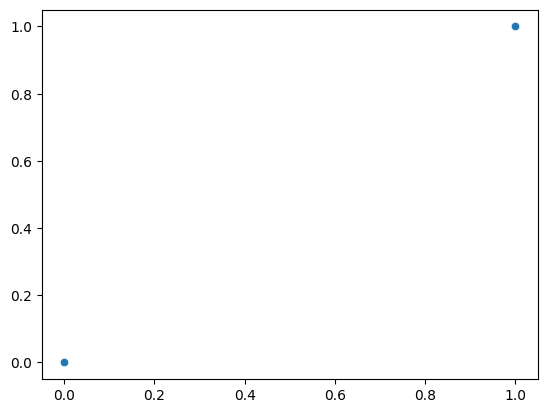

In [71]:
sns.scatterplot(x = y_pred, y = y_test)

In [72]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [73]:
print(accuracy_score(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))
print(classification_report(y_pred, y_test))

1.0
[[44  0]
 [ 0 17]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        17

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61

